In [1]:
!pip install -q underthesea
!pip install -q rouge-score
!pip install -q flash_attn
!pip install -q underthesea rouge-score sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.6/978.6 kB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 56.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 108.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
category-encoders 2.7.0 requires scikit-learn<1.6.0,>=1.0.0, but you have scikit-learn 1.7.2 which is incompatible.
cesium 0.12.4 requires numpy<3.0,>=2.0, but you have numpy 1.26.4 which is incompatible.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.2 which is incompatible.
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 74.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# !pip install -q underthesea
import os, re, json, string, pickle, random
from collections import Counter
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from underthesea import word_tokenize, text_normalize
import matplotlib.pyplot as plt

In [3]:
DATA_DIR      = "/kaggle/input/data-nlp-bai-2"     # df_train.csv, df_test.csv
FEATURES_PKL  = "/kaggle/input/clip_feautres/pytorch/default/1/clip_features.pkl"      # CLIP ViT-B/32 (laion2b_s34b_b79k)
ARTIFACTS_DIR = "artifacts"                        # nơi lưu/đọc vocab
OUT_DIR       = "artifacts_transdec"               # checkpoints, logs
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
os.makedirs(os.path.join(OUT_DIR, "checkpoints"), exist_ok=True)

In [4]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

assert os.path.exists(os.path.join(DATA_DIR, "df_train.csv"))
assert os.path.exists(os.path.join(DATA_DIR, "df_test.csv"))
assert os.path.exists(FEATURES_PKL)

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# load data

In [6]:
df_train = pd.read_csv(os.path.join(DATA_DIR, "df_train.csv")).sort_values("image_id").reset_index(drop=True)
df_val   = pd.read_csv(os.path.join(DATA_DIR, "df_test.csv")).sort_values("image_id").reset_index(drop=True)
print("Train/Val:", df_train.shape, df_val.shape)

Train/Val: (240520, 5) (60130, 5)


# Vietnamese normalize + tokenize (giữ token có "_")

In [7]:
VN_PUNCTS = set(string.punctuation) - set(['_'])
VN_PUNCTS |= {"“","”","’","‘","–","—","…","•","·","→","←","►","®","™","©"}
SPECIALS = ["<unk>", "<pad>", "<sos>", "<eos>"]
UNK, PAD, SOS, EOS = 0, 1, 2, 3

def vn_normalize(s: str) -> str:
    s = str(s)
    s = text_normalize(s)
    s = s.lower()
    s = "".join(ch if ch not in VN_PUNCTS else " " for ch in s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

def vn_tokenize(s: str) -> list:
    s = vn_normalize(s)
    keep = [t for t in s.split() if "_" in t]
    remain = " ".join([t for t in s.split() if "_" not in t])
    toks = word_tokenize(remain, format="text").split() if remain else []
    return keep + toks

# Build vocab

In [8]:
def build_vocab(texts, min_freq=2, max_size=None, desc="Build Vocab"):
    counter = Counter()
    for t in tqdm(texts, desc=desc):
        counter.update(vn_tokenize(t))
    items = [(w,c) for w,c in counter.items() if c >= min_freq]
    items.sort(key=lambda x:(-x[1], x[0]))
    if max_size is not None: items = items[:max_size]
    vocab = {sp:i for i,sp in enumerate(SPECIALS)}
    idx = len(SPECIALS)
    for w,_ in items:
        if w not in vocab:
            vocab[w] = idx; idx += 1
    return vocab, {i:w for w,i in vocab.items()}

vq_path = os.path.join(ARTIFACTS_DIR, "vocab_questions.pkl")
va_path = os.path.join(ARTIFACTS_DIR, "vocab_answers.pkl")
if os.path.exists(vq_path) and os.path.exists(va_path):
    with open(vq_path, "rb") as f: vocab_q = pickle.load(f)
    with open(va_path, "rb") as f: vocab_a = pickle.load(f)
    print("Loaded vocabs:", len(vocab_q), len(vocab_a))
else:
    vocab_q, _ = build_vocab(df_train["question"].astype(str), min_freq=2, max_size=40000, desc="Vocab Q")
    vocab_a, _ = build_vocab(df_train["answer"].astype(str),   min_freq=2, max_size=60000, desc="Vocab A")
    with open(vq_path,"wb") as f: pickle.dump(vocab_q,f)
    with open(va_path,"wb") as f: pickle.dump(vocab_a,f)
    print("Built & saved vocabs:", len(vocab_q), len(vocab_a))

itos_a = {i:w for w,i in vocab_a.items()}


Vocab A: 100%|██████████| 240520/240520 [06:35<00:00, 608.91it/s]


Built & saved vocabs: 19758 60004


# Max length (p95) + encode

In [9]:
def estimate_len_percentile(texts, p=0.95):
    lens = [len(vn_tokenize(t))+2 for t in texts]  # +<sos>/<eos>
    return int(np.percentile(lens, p*100))

LEN_Q = max(12, estimate_len_percentile(df_train["question"]))
LEN_A = max(24, estimate_len_percentile(df_train["answer"]))
print(f"Pic2A | LEN_Q: {LEN_Q} | LEN_A: {LEN_A}")

def encode_text(text, vocab, max_len):
    toks = vn_tokenize(text)
    ids  = [SOS] + [vocab.get(t, UNK) for t in toks] + [EOS]
    ids  = ids[:max_len]
    ids += [PAD]*(max_len - len(ids))
    return ids

def encode_df(df):
    q_ids, a_ids, img_ids = [], [], []
    for _, row in tqdm(df.iterrows(), total=len(df), desc="Encoding DF"):
        q_ids.append(encode_text(str(row["question"]), vocab_q, LEN_Q))
        a_ids.append(encode_text(str(row["answer"]),   vocab_a, LEN_A))
        img_ids.append(str(row["image_id"]))
    return (torch.tensor(np.array(q_ids), dtype=torch.long),
            torch.tensor(np.array(a_ids), dtype=torch.long),
            img_ids)

train_q_ids, train_a_ids, train_img_ids = encode_df(df_train)
val_q_ids,   val_a_ids,   val_img_ids   = encode_df(df_val)


Pic2A | LEN_Q: 22 | LEN_A: 84


Encoding DF: 100%|██████████| 60130/60130 [02:18<00:00, 434.54it/s]


# Load CLIP features (ViT-B/32, laion2b_s34b_b79k)

In [10]:
with open(FEATURES_PKL, "rb") as f:
    clip_feats = pickle.load(f)

def get_feat(image_id: str):
    arr = np.array(clip_feats[str(image_id)])
    if arr.ndim == 2 and arr.shape[0] == 1:
        arr = arr[0]
    return arr.astype("float32")

FEATURE_DIM = get_feat(train_img_ids[0]).shape[-1]
print("FEATURE_DIM:", FEATURE_DIM)


FEATURE_DIM: 512


# Dataset/DataLoader

In [11]:
class EncodedPackDataset(Dataset):
    def __init__(self, q_ids, a_ids, img_ids):
        self.q_ids, self.a_ids, self.img_ids = q_ids, a_ids, img_ids
    def __len__(self): return self.q_ids.size(0)
    def __getitem__(self, i):
        f = get_feat(self.img_ids[i])
        return {
            "image_feat": torch.tensor(f, dtype=torch.float32),
            "q_ids":      self.q_ids[i],
            "a_ids":      self.a_ids[i],
        }

BATCH = 64            # điều chỉnh theo VRAM (LEN_Q=22, LEN_A=84 → 64 thường ổn trên 16GB)
VAL_BATCH = 64
ACCUM_STEPS = 1       # tăng nếu muốn effective batch lớn hơn (vd 2 → gấp đôi)
USE_AMP = True

In [12]:
train_ds = EncodedPackDataset(train_q_ids, train_a_ids, train_img_ids)
val_ds   = EncodedPackDataset(val_q_ids,   val_a_ids,   val_img_ids)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=8, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=VAL_BATCH, shuffle=False, num_workers=8, pin_memory=True)

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 4, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


# Model — Pic2A-TransDec

In [13]:
class Pic2ATransDec(nn.Module):
    def __init__(self, feature_dim, vocab_q_size, vocab_a_size,
                 d_model=512, nhead=8, num_enc_layers=4, num_dec_layers=4,
                 dim_feedforward=2048, dropout=0.1,
                 len_q=32, len_a=64, pad_idx=1, v_tokens=8):
        super().__init__()
        self.len_a   = len_a
        self.pad_idx = pad_idx
        self.d_model = d_model
        self.v_tokens= v_tokens

        self.img_proj = nn.Sequential(nn.Linear(feature_dim, d_model), nn.ReLU(), nn.Dropout(dropout))
        self.visual_expander = nn.Parameter(torch.randn(v_tokens, d_model))

        self.q_emb = nn.Embedding(vocab_q_size, d_model, padding_idx=pad_idx)
        self.q_pos = nn.Parameter(torch.randn(1024, d_model))

        self.a_emb = nn.Embedding(vocab_a_size, d_model, padding_idx=pad_idx)
        self.a_pos = nn.Parameter(torch.randn(1024, d_model))

        enc_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
        dec_layer = nn.TransformerDecoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_enc_layers)
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_dec_layers)

        self.out = nn.Linear(d_model, vocab_a_size)

    def _visual_tokens(self, img_feat):
        b = img_feat.size(0)
        base = self.img_proj(img_feat)                           # (B,d_model)
        vt = self.visual_expander.unsqueeze(0).expand(b, self.v_tokens, self.d_model)
        return vt + base.unsqueeze(1)                             # (B,V,d_model)

    def forward(self, img_feat, q_ids, a_ids=None):
        device = img_feat.device
        vtok = self._visual_tokens(img_feat)                      # (B,V,d_model)

        q_len = q_ids.size(1)
        q = self.q_emb(q_ids) + self.q_pos[:q_len,:].unsqueeze(0) # (B,Tq,d_model)
        enc_q = self.encoder(q)                                   # (B,Tq,d_model)

        memory = torch.cat([vtok, enc_q], dim=1)                  # (B,V+Tq,d_model)

        if a_ids is None:  # greedy inference
            ys = torch.full((img_feat.size(0),1), SOS, dtype=torch.long, device=device)
            for _ in range(self.len_a):
                tgt = self.a_emb(ys) + self.a_pos[:ys.size(1), :].unsqueeze(0)
                T = tgt.size(1)
                causal = torch.triu(torch.ones(T, T, device=device)*float('-inf'), diagonal=1)
                dec_out = self.decoder(tgt, memory, tgt_mask=causal)
                next_tok = torch.argmax(self.out(dec_out[:, -1, :]), dim=-1, keepdim=True)
                ys = torch.cat([ys, next_tok], dim=1)
                if (next_tok.squeeze(-1) == EOS).all(): break
            return ys[:,1:]
        else:                # training
            tgt_inp = a_ids[:, :-1]
            tgt_gold= a_ids[:,  1:]
            tgt = self.a_emb(tgt_inp) + self.a_pos[:tgt_inp.size(1), :].unsqueeze(0)
            T = tgt.size(1)
            causal = torch.triu(torch.ones(T, T, device=device)*float('-inf'), diagonal=1)
            dec_out = self.decoder(tgt, memory, tgt_mask=causal)
            logits = self.out(dec_out)                            # (B,T,vocab)
            return logits, tgt_gold

# Optimizer, Scheduler, EarlyStopping

In [14]:
model = Pic2ATransDec(
    feature_dim=FEATURE_DIM,
    vocab_q_size=len(vocab_q),
    vocab_a_size=len(vocab_a),
    d_model=512, nhead=8,
    num_enc_layers=4, num_dec_layers=4,
    dim_feedforward=2048, dropout=0.1,
    len_q=LEN_Q, len_a=LEN_A, pad_idx=PAD, v_tokens=8
).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=PAD)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=1, verbose=True)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

class EarlyStopping:
    def __init__(self, patience=3, min_delta=1e-4):
        self.patience = patience
        self.min_delta = min_delta
        self.best = float('inf')
        self.num_bad = 0
        self.stopped_epoch = None
    def step(self, val_loss, epoch):
        improved = (self.best - val_loss) > self.min_delta
        if improved:
            self.best = val_loss
            self.num_bad = 0
        else:
            self.num_bad += 1
            if self.num_bad >= self.patience:
                self.stopped_epoch = epoch
                return True
        return False

MAX_EPOCHS = 10          # tổng epoch tối đa (early stop sẽ dừng sớm)
PATIENCE   = 3
early_stop = EarlyStopping(patience=PATIENCE, min_delta=1e-4)

/tmp/ipykernel_19/34630801.py:14: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


# Train/Val runners (AMP + Grad Accum + clip grad)

In [15]:
def run_one_epoch(loader, train_mode=True):
    if train_mode: model.train()
    else:          model.eval()
    total, steps = 0.0, 0
    optimizer.zero_grad(set_to_none=True)
    with torch.set_grad_enabled(train_mode):
        for step, batch in enumerate(tqdm(loader, desc="train" if train_mode else "val")):
            img = batch["image_feat"].to(device, non_blocking=True)
            q   = batch["q_ids"].to(device, non_blocking=True)
            a   = batch["a_ids"].to(device, non_blocking=True)

            if train_mode:
                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    logits, tgt = model(img, q, a_ids=a)
                    loss = criterion(logits.reshape(-1, logits.size(-1)), tgt.reshape(-1))
                    loss = loss / ACCUM_STEPS
                scaler.scale(loss).backward()
                if (step + 1) % ACCUM_STEPS == 0:
                    scaler.unscale_(optimizer)
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    scaler.step(optimizer)
                    scaler.update()
                    optimizer.zero_grad(set_to_none=True)
                total += float(loss.item() * ACCUM_STEPS)
            else:
                with torch.cuda.amp.autocast(enabled=USE_AMP):
                    logits, tgt = model(img, q, a_ids=a)
                    loss = criterion(logits.reshape(-1, logits.size(-1)), tgt.reshape(-1))
                total += float(loss.item())
            steps += 1
    return total / max(steps, 1)

# Training loop + checkpoints + logs

In [16]:
best_val = float("inf")
log_rows = []
log_csv  = os.path.join(OUT_DIR, "train_val_log.csv")
best_path= os.path.join(OUT_DIR, "best.pth")

for ep in range(1, MAX_EPOCHS+1):
    print(f"\n===== Epoch {ep}/{MAX_EPOCHS} =====")
    train_loss = run_one_epoch(train_loader, train_mode=True)
    val_loss   = run_one_epoch(val_loader,   train_mode=False)

    row = {"epoch": ep, "train_loss_epoch": train_loss, "val_loss_epoch": val_loss,
           "lr": optimizer.param_groups[0]["lr"]}
    log_rows.append(row)
    print(row)

    # save checkpoint mỗi epoch
    ckpt_path = os.path.join(OUT_DIR, "checkpoints", f"epoch_{ep:02d}.pth")
    torch.save({
        "epoch": ep,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "config": {
            "feature_dim": FEATURE_DIM, "LEN_Q": LEN_Q, "LEN_A": LEN_A,
            "pad": PAD, "sos": SOS, "eos": EOS,
            "vocab_q_size": len(vocab_q), "vocab_a_size": len(vocab_a),
            "d_model": 512, "nhead": 8, "num_enc_layers":4, "num_dec_layers":4,
            "dim_feedforward": 2048, "v_tokens": 8
        }
    }, ckpt_path)
    print("Saved checkpoint:", ckpt_path)

    # best.pth
    if val_loss < best_val:
        best_val = val_loss
        torch.save({"epoch": ep, "val_loss": val_loss, "state_dict": model.state_dict()}, best_path)
        print("** Best updated:", best_path, "| val_loss:", best_val)

    # scheduler + early stop
    scheduler.step(val_loss)
    if early_stop.step(val_loss, ep):
        print(f"Early stopped at epoch {ep} (best val_loss {early_stop.best:.4f})")
        break


===== Epoch 1/10 =====


train:   0%|          | 0/3759 [00:00<?, ?it/s]/tmp/ipykernel_19/3556773320.py:13: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
val:   0%|          | 0/940 [00:00<?, ?it/s]/tmp/ipykernel_19/3556773320.py:26: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
val: 100%|██████████| 940/940 [01:32<00:00, 10.19it/s]


{'epoch': 1, 'train_loss_epoch': 5.065146752322218, 'val_loss_epoch': 4.241616452247539, 'lr': 0.0002}
Saved checkpoint: artifacts_transdec/checkpoints/epoch_01.pth
** Best updated: artifacts_transdec/best.pth | val_loss: 4.241616452247539

===== Epoch 2/10 =====


val: 100%|██████████| 940/940 [01:32<00:00, 10.19it/s]


{'epoch': 2, 'train_loss_epoch': 4.022348717382278, 'val_loss_epoch': 3.805329891468616, 'lr': 0.0002}
Saved checkpoint: artifacts_transdec/checkpoints/epoch_02.pth
** Best updated: artifacts_transdec/best.pth | val_loss: 3.805329891468616

===== Epoch 3/10 =====


...

{'epoch': 8, 'train_loss_epoch': 2.8752648654089357, 'val_loss_epoch': 3.401925951622902, 'lr': 0.0002}
Saved checkpoint: artifacts_transdec/checkpoints/epoch_08.pth
** Best updated: artifacts_transdec/best.pth | val_loss: 3.401925951622902

===== Epoch 9/10 =====


val: 100%|██████████| 940/940 [01:30<00:00, 10.38it/s]


{'epoch': 9, 'train_loss_epoch': 2.7968791669022055, 'val_loss_epoch': 3.3954582168700846, 'lr': 0.0002}
Saved checkpoint: artifacts_transdec/checkpoints/epoch_09.pth
** Best updated: artifacts_transdec/best.pth | val_loss: 3.3954582168700846

===== Epoch 10/10 =====


val: 100%|██████████| 940/940 [01:31<00:00, 10.27it/s]


{'epoch': 10, 'train_loss_epoch': 2.7297501023635804, 'val_loss_epoch': 3.400433675786282, 'lr': 0.0002}
Saved checkpoint: artifacts_transdec/checkpoints/epoch_10.pth


Wrote log: artifacts_transdec/train_val_log.csv


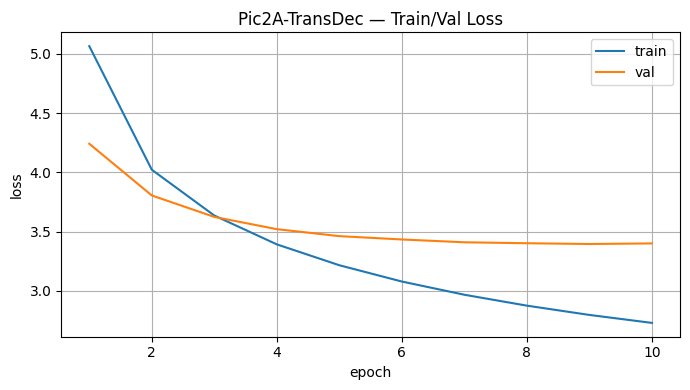

Done. Best ckpt: artifacts_transdec/best.pth  | all ckpts in: artifacts_transdec/checkpoints


In [17]:
pd.DataFrame(log_rows).to_csv(log_csv, index=False)
print("Wrote log:", log_csv)

plt.figure(figsize=(7,4))
plt.plot([r["epoch"] for r in log_rows], [r["train_loss_epoch"] for r in log_rows], label="train")
plt.plot([r["epoch"] for r in log_rows], [r["val_loss_epoch"] for r in log_rows], label="val")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.title("Pic2A-TransDec — Train/Val Loss")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "loss_curve.png")); plt.show()

print("Done. Best ckpt:", best_path, " | all ckpts in:", os.path.join(OUT_DIR, "checkpoints"))

===============================

# inport library